In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import glob
import re
from matplotlib.ticker import FormatStrFormatter

In [2]:
genome=[30427671,19698289,23459830,18585056,26975502]
space=2000000
chr1=30427671 / 2 
chr2=30427671 + 19698289 / 2 + space
chr3=30427671 + 19698289 + 23459830 / 2 + space * 2
chr4=30427671 + 19698289 + 23459830 + 18585056 / 2 + space * 3
chr5=30427671 + 19698289 + 23459830 + 18585056 + 26975502 / 2 + space * 4

In [3]:
def parse(assoc):
    df = pd.read_table(assoc)
    df['P'] = -(np.log10(df['p_lrt']))
    df['P_bi'] = (np.log10(df['p_lrt']))
    space=2000000
    df['position'] = np.select([df['chr'] == 1, 
                                                df['chr'] == 2, 
                                                df['chr'] == 3, 
                                                df['chr'] == 4, 
                                                df['chr'] == 5],
                        [df['ps'], 
                        df['ps'] + 30427671 + space, 
                        df['ps'] + 30427671 + 19698289 + space * 2,
                        df['ps'] + 30427671 + 19698289 + 23459830 + space * 3,
                        df['ps'] + 30427671 + 19698289 + 23459830 + 18585056 + space * 4])
    return(df)
classic=parse('690_Mg_blues.assoc.txt.gz')

In [4]:
classic.head()

,chr,rs,ps,n_miss,allele1,allele0,af,beta,se,l_remle,l_mle,p_wald,p_lrt,p_score,P,P_bi,position
0,1,1:346,346,30,T,C,0.353,-29.27495,29.94996,2.770104,2.817164,0.328684,0.329381,0.330298,0.482301,-0.482301,346
1,1,1:353,353,25,A,G,0.087,-34.84241,45.02532,2.830828,2.882697,0.439291,0.437183,0.438136,0.359337,-0.359337,353
2,1,1:363,363,20,G,C,0.072,12.70881,44.83997,2.794127,2.847708,0.776936,0.777031,0.777132,0.109562,-0.109562,363
3,1,1:425,425,31,T,C,0.115,-28.59364,38.18371,2.824744,2.877953,0.454207,0.452112,0.452915,0.344754,-0.344754,425
4,1,1:471,471,23,G,T,0.108,-35.80226,39.56215,2.826970,2.879481,0.365802,0.363990,0.364818,0.438910,-0.438910,471


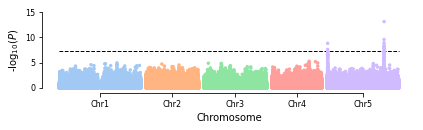

In [46]:
cm = 1/2.54
# fig = plt.figure(figsize=(16,4))
fig = plt.figure(figsize=(17*cm,4*cm))
ax = sns.scatterplot(x='position',
                y='P',
                data=classic,
                hue='chr',
                palette='pastel',
                marker='o',
                s=12,
                linewidth=0,
                legend=False,
                zorder=2)
plt.hlines(y=-np.log10(0.05/len(classic)),
             xmin=min(classic['position']),
             xmax=max(classic['position']),
             color='0',
             linestyle='--',
             linewidth=1,
#              alpha=0.4,
             zorder=1)
ax.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
plt.xlabel('Chromosome',fontsize=10)
plt.ylim(-1,16)
plt.ylabel('-log$_{10}$($\itP$)',fontsize=10)
plt.xticks([chr1,chr2,chr3,chr4,chr5],["Chr1", "Chr2", "Chr3", "Chr4", "Chr5"])
sns.despine(trim=True)
plt.tick_params(labelsize=8)
# plt.savefig("Fig2a.pdf", format="pdf",bbox_inches="tight")
# plt.savefig("Fig2a.png", format="png",bbox_inches="tight",facecolor="w",dpi=400)

In [47]:
classic.sort_values(by='P',ascending=False).head(10)

,chr,rs,ps,n_miss,allele1,allele0,af,beta,se,l_remle,l_mle,p_wald,p_lrt,p_score,P,P_bi,position
811509,5,5:21405867,21405867,54,G,A,0.088,-301.7630,39.38823,2.328811,2.369639,6.271519e-14,7.228329e-14,7.505019e-13,13.140962,-13.140962,121576713
811307,5,5:21392702,21392702,11,C,G,0.081,260.8489,40.67973,2.580336,2.633706,2.664290e-10,2.621355e-10,8.418870e-10,9.581474,-9.581474,121563548
811304,5,5:21392089,21392089,21,A,C,0.079,258.8815,41.92797,2.481048,2.528626,1.134956e-09,1.188955e-09,3.416293e-09,8.924835,-8.924835,121562935
648935,5,5:282011,282011,39,C,T,0.183,183.6735,29.88552,2.401857,2.440341,1.346265e-09,1.501480e-09,4.515572e-09,8.823480,-8.823480,100452857
811454,5,5:21401216,21401216,61,G,A,0.056,-295.4570,49.02923,2.431869,2.476155,2.736597e-09,2.983539e-09,8.102083e-09,8.525268,-8.525268,121572062
811312,5,5:21393289,21393289,5,T,C,0.055,-277.0624,47.22815,2.429708,2.474010,6.916865e-09,7.580551e-09,1.892023e-08,8.120299,-8.120299,121564135
811321,5,5:21394066,21394066,5,C,T,0.054,-280.9186,47.91494,2.446091,2.490400,7.061572e-09,7.640688e-09,1.887744e-08,8.116868,-8.116868,121564912
811318,5,5:21393829,21393829,13,T,C,0.080,239.5910,41.88617,2.610421,2.661995,1.588727e-08,1.565652e-08,3.369683e-08,7.805305,-7.805305,121564675
811309,5,5:21392816,21392816,15,A,T,0.399,139.3375,24.64999,2.736633,2.786499,2.315718e-08,2.202013e-08,4.503720e-08,7.657180,-7.657180,121563662
648928,5,5:280952,280952,17,G,C,0.217,159.1699,28.16340,2.489594,2.529364,2.328414e-08,2.453459e-08,5.410848e-08,7.610221,-7.610221,100451798


In [40]:
significant=classic[classic['P'] > -np.log10(0.05/len(classic))]
significant

,chr,rs,ps,n_miss,allele1,allele0,af,beta,se,l_remle,l_mle,p_wald,p_lrt,p_score,P,P_bi,position
504334,5,5:273701,273701,57,C,T,0.224,158.8664,29.16291,2.407041,2.442610,7.117090e-08,7.056651e-08,1.352970e-07,7.151401,-7.151401,100444547
504411,5,5:276733,276733,52,T,C,0.218,160.0056,29.17611,2.450246,2.487995,5.840743e-08,5.687588e-08,1.092622e-07,7.245072,-7.245072,100447579
504458,5,5:282011,282011,55,C,T,0.184,186.7355,30.43402,2.227168,2.259838,1.430395e-09,1.576582e-09,4.685314e-09,8.802283,-8.802283,100452857
504463,5,5:282729,282729,39,A,G,0.180,177.7215,30.86971,2.270604,2.304561,1.289105e-08,1.380952e-08,3.246946e-08,7.859821,-7.859821,100453575
629765,5,5:21392702,21392702,38,C,G,0.081,247.5062,41.78422,2.276008,2.317495,4.980699e-09,5.291854e-09,1.330665e-08,8.276392,-8.276392,121563548
629767,5,5:21392816,21392816,54,A,T,0.387,140.4364,25.55393,2.400849,2.440555,5.485829e-08,5.448310e-08,1.064022e-07,7.263738,-7.263738,121563662
629770,5,5:21393289,21393289,32,T,C,0.056,-273.8514,48.61722,2.216384,2.254102,2.585360e-08,2.909097e-08,6.583506e-08,7.536242,-7.536242,121564135
629776,5,5:21393829,21393829,46,T,C,0.078,245.5717,44.06055,2.318546,2.358250,3.586492e-08,3.724153e-08,7.749264e-08,7.428972,-7.428972,121564675
629779,5,5:21394066,21394066,37,C,T,0.055,-282.2271,49.29640,2.226706,2.264292,1.544233e-08,1.717744e-08,4.035054e-08,7.765042,-7.765042,121564912
629863,5,5:21401216,21401216,68,G,A,0.056,-291.6908,49.34777,2.244343,2.284271,5.354544e-09,5.839649e-09,1.486506e-08,8.233613,-8.233613,121572062


In [41]:
significant[['chr','ps']].to_csv('690_Mg_blues_significantSNPs_20250128.txt',index=None,header=None,sep='\t')

In [42]:
for i in classic[classic['P'] > -np.log10(0.05/len(classic))].P.values:
    print(i)

7.151401360888409
7.245071870753513
8.802283436129915
7.859821416640354
8.2763921463192
7.263738189740799
7.536241797535199
7.428972485131408
7.765041559754856
8.233613255960252
7.272507380170502
12.649760512534089


In [38]:
classic[classic['P'] > -np.log10(0.05/len(classic))]

,chr,rs,ps,n_miss,allele1,allele0,af,beta,se,l_remle,l_mle,p_wald,p_lrt,p_score,P,P_bi,position
504334,5,5:273701,273701,57,C,T,0.224,158.8664,29.16291,2.407041,2.442610,7.117090e-08,7.056651e-08,1.352970e-07,7.151401,-7.151401,100444547
504411,5,5:276733,276733,52,T,C,0.218,160.0056,29.17611,2.450246,2.487995,5.840743e-08,5.687588e-08,1.092622e-07,7.245072,-7.245072,100447579
504458,5,5:282011,282011,55,C,T,0.184,186.7355,30.43402,2.227168,2.259838,1.430395e-09,1.576582e-09,4.685314e-09,8.802283,-8.802283,100452857
504463,5,5:282729,282729,39,A,G,0.180,177.7215,30.86971,2.270604,2.304561,1.289105e-08,1.380952e-08,3.246946e-08,7.859821,-7.859821,100453575
629765,5,5:21392702,21392702,38,C,G,0.081,247.5062,41.78422,2.276008,2.317495,4.980699e-09,5.291854e-09,1.330665e-08,8.276392,-8.276392,121563548
629767,5,5:21392816,21392816,54,A,T,0.387,140.4364,25.55393,2.400849,2.440555,5.485829e-08,5.448310e-08,1.064022e-07,7.263738,-7.263738,121563662
629770,5,5:21393289,21393289,32,T,C,0.056,-273.8514,48.61722,2.216384,2.254102,2.585360e-08,2.909097e-08,6.583506e-08,7.536242,-7.536242,121564135
629776,5,5:21393829,21393829,46,T,C,0.078,245.5717,44.06055,2.318546,2.358250,3.586492e-08,3.724153e-08,7.749264e-08,7.428972,-7.428972,121564675
629779,5,5:21394066,21394066,37,C,T,0.055,-282.2271,49.29640,2.226706,2.264292,1.544233e-08,1.717744e-08,4.035054e-08,7.765042,-7.765042,121564912
629863,5,5:21401216,21401216,68,G,A,0.056,-291.6908,49.34777,2.244343,2.284271,5.354544e-09,5.839649e-09,1.486506e-08,8.233613,-8.233613,121572062
